In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
# from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme
from compressibleSPH.caseUtils.sedov.initial import buildSedov
goalRadius = 0.8

gamma = 5/3
rho0 = 1
E0 = 1

nx = 800
# gamma = 5/3
# leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
)


SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch

In [3]:
display(compressibleSPHConfig)

CompSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Monaghan: 1>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=2,
	Cu_l=1,
	Cu_q=2,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CompSPH', energyScheme=<EnergyScheme.CRK: 5>)

In [4]:
compSystem = buildSedov(
    SimulationSystem, SimulationState, 
    config = config,
    nx = nx, dim = dim, domainExtent = L, 
    periodicDomain = True, 
    rho0 = rho0, E0 = E0, 
    initialization = 'singular', 
    gamma = gamma, kernel = config.kernel, 
    targetNeighbors = config.targetNeighbors, 
    dtype = config.dtype, device = config.device)

Module sphWarpCore.radiusSearch.wp_compactHash 1c74884 load on device 'cuda:0' took 2.40 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 57e75fd load on device 'cuda:0' took 2.94 ms  (cached)
Module sphWarpCore.operations.wp_density 1f9d9f0 load on device 'cuda:0' took 2.71 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 1a2649b load on device 'cuda:0' took 2.51 ms  (cached)


In [5]:
# from compressibleSPH.modules.timestep.compressible import computeTimestep

# config.adaptiveDt = True
# config.dt = computeTimestep(compSystem, config, compressibleSPHConfig, dt = config.dt)
# print(f'Initial timestep: {config.dt}')

In [6]:
from compressibleSPH.caseUtils.sedov.sedovSolution import SedovSolution, radius, beta
from scipy.optimize import minimize

answer = SedovSolution(
    nDim = dim,
    gamma = gamma,
    rho0 = rho0,
    E0 = E0,
    h0 = 2/nx
)
nu1 = 1.0/(answer.nu + 2.0)
nu2 = 2.0*nu1
goalTime = (goalRadius*(answer.alpha*rho0/E0)**nu1)**(1.0/nu2)
vs, r2, v2, rho2, P2 = answer.shockState(goalTime)
rad_t = lambda t: radius(beta(dim), E0, t, rho0, 1)

targetTime = minimize(lambda t: (rad_t(t) - goalRadius) ** 2, 0.2).x[0]

print(f'Target Time [paper]: {targetTime:8.4g}, {rad_t(targetTime):8.4g} / {answer.shockState(targetTime)[1]:8.4g}')
print(f'Target Time  [code]: {goalTime:8.4g}, {rad_t(goalTime):8.4g} / {answer.shockState(goalTime)[1]:8.4g}')

Target Time [paper]:   0.6119,      0.8 /   0.8531
Target Time  [code]:   0.5556,   0.7502 /      0.8


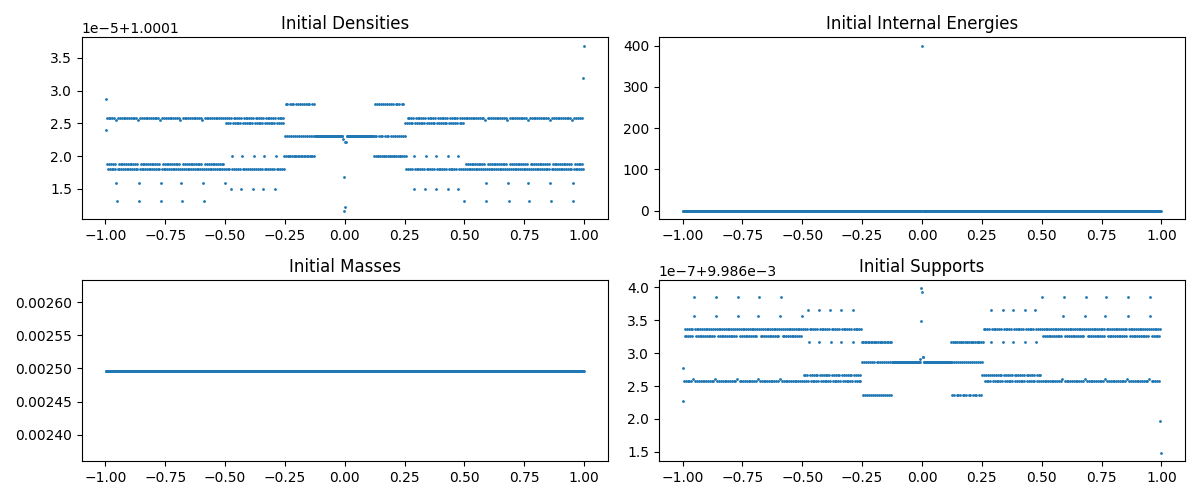

In [7]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

In [8]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [9]:
# runningState = compSystem.initializeNewState()

# result = integrator.function(
#     state = runningState,
#     f = fn,
#     dt = config.dt,  
#     config = config,
#     compParams = compressibleSPHConfig,
#     verbose = False,
# )

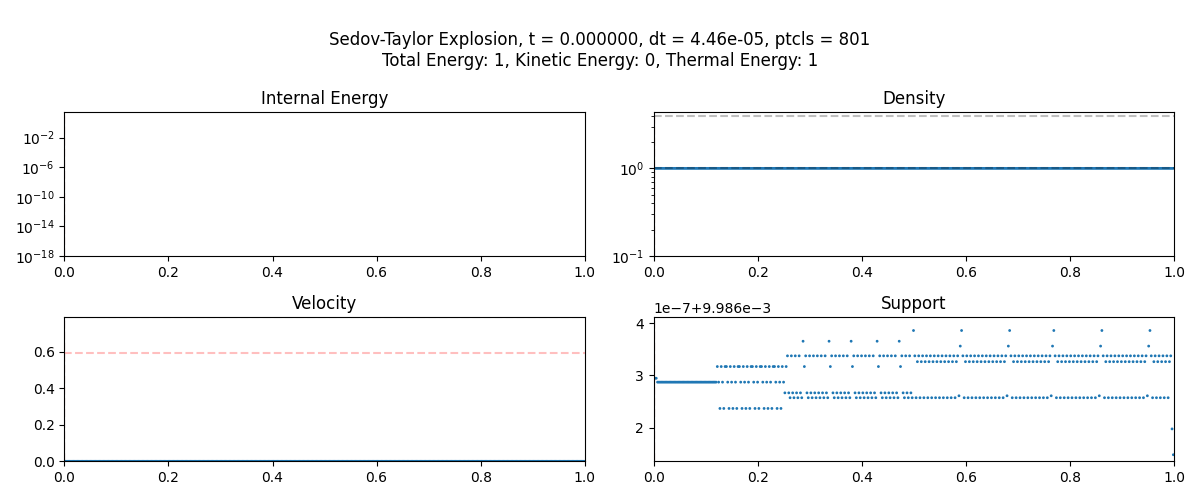

In [10]:


def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, rho2*1.1)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

def plotState(fig, axis, state):

    axis[0,0].scatter(state.state.positions.cpu().numpy(), state.state.internalEnergies.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[0,1].scatter(state.state.positions.cpu().numpy(), state.state.densities.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[1,0].scatter(state.state.positions.cpu().numpy(), state.state.velocities.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)
    axis[1,1].scatter(state.state.positions.cpu().numpy(), state.state.supports.cpu().numpy(), s = state.state.supports.cpu().numpy() * 100)

    axis[0,0].set_title('Internal Energy')
    axis[0,1].set_title('Density')
    axis[1,0].set_title('Velocity')
    axis[1,1].set_title('Support')

    kineticEnergy = 0.5 * (torch.linalg.norm(state.state.velocities, dim = -1) **2 * state.state.masses).sum()
    thermalEnergy = (state.state.internalEnergies * state.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    fig.suptitle(f'\nSedov-Taylor Explosion, t = {state.t:2f}, dt = {config.dt:.3g}, ptcls = {len(state.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
    fig.tight_layout()

    # prefix = './images/sedov_1d_201_sharp/'
    # os.makedirs(prefix, exist_ok = True)

    rt = rad_t(state.t)
    # vt = vel_t(state.t)
        
    t = state.t.cpu() if isinstance(state.t, torch.Tensor) else state.t
    setupPlot(axis, t)
    

# t = t * initial_dt.cpu().item() / config.dt
# print(f"Adjusted time for plotting: {t}")
# print(initial_dt)
# setupPlot(axis, t)
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotState(fig, axis, compSystem)
fig.tight_layout()

# fig.savefig(f'{prefix}/frame_{0:06d}.png')
# display(fig)

In [ ]:
# config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 128

runningState = compSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if i % 50 == 0:
        axis[0,0].cla()
        axis[0,1].cla()
        axis[1,0].cla()
        axis[1,1].cla()
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()

Running with dt: 4.4636079110205173e-05, which gives nSteps: 12447


  0%|          | 0/12447 [00:00<?, ?it/s]

Module sphWarpCore.crk.crk_volume 332e775 load on device 'cuda:0' took 2.64 ms  (cached)
Module sphWarpCore.crk.crk_moments ed53dfd load on device 'cuda:0' took 2.59 ms  (cached)
Module sphWarpCore.crk.crk_density ce8cba3 load on device 'cuda:0' took 3.17 ms  (cached)
Module sphWarpCore.operations.wp_gradient 8af5a8b load on device 'cuda:0' took 3.46 ms  (cached)
Module compressibleSPH.modules.crk.accel 08cc396 load on device 'cuda:0' took 4.37 ms  (cached)
Module compressibleSPH.modules.crk.dudt 66db9c2 load on device 'cuda:0' took 2.54 ms  (cached)
Module compressibleSPH.modules.compSPH.balance db159de load on device 'cuda:0' took 2.56 ms  (cached)


In [ ]:
times = [x[1].cpu().item() for x in trajectory]

AttributeError: 'float' object has no attribute 'cpu'

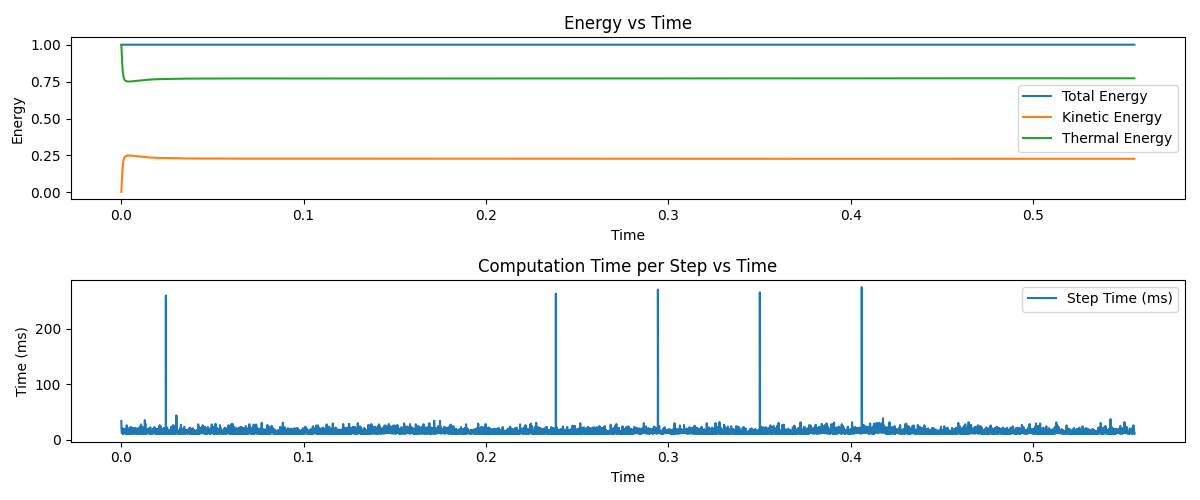

In [ ]:
fig, axis = plt.subplots(2,1, figsize = (12, 5), squeeze = False)

axis[0,0].plot(times, [x[2] for x in trajectory], label = 'Total Energy')
axis[0,0].plot(times, [x[3] for x in trajectory], label = 'Kinetic Energy')
axis[0,0].plot(times, [x[4] for x in trajectory], label = 'Thermal Energy')
axis[0,0].legend()
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Energy')
axis[0,0].set_title('Energy vs Time')

axis[1,0].plot(times, [x[5] for x in trajectory], label = 'Step Time (ms)')
axis[1,0].legend()
axis[1,0].set_xlabel('Time')
axis[1,0].set_ylabel('Time (ms)')
axis[1,0].set_title('Computation Time per Step vs Time')

fig.tight_layout()

In [ ]:
print(f'Mean computation time per step: {sum(x[5] for x in trajectory)/len(trajectory):.3f} ms')
print(f'Max computation time for a step: {max(x[5] for x in trajectory):.3f} ms')
print(f'Stddev of computation time for steps: {torch.tensor([x[5] for x in trajectory]).std():.3f} ms')

Mean computation time per step: 14.719 ms
Max computation time for a step: 274.776 ms
Stddev of computation time for steps: 6.813 ms
